# Negentropy reduction — keep structure, not variance
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/20_negentropy_reduction.ipynb)

PCA keeps the **highest-variance** axes. `RBIGReducer` keeps the axes
that carry the most **non-Gaussian structure** (negentropy) after
whitening — so a low-variance bimodal signal survives while a
high-variance Gaussian nuisance axis is dropped. This is exactly the
regime where a variance criterion fails.

> **Colab / fresh environment?** Run the cell below to install `rbig`.
> Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from rbig import RBIGReducer

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data: structure hides in a low-variance axis

Axis 0 is a **high-variance Gaussian** (nuisance). Axis 1 is a
**low-variance bimodal** signal (structure). Remaining axes are
standard-normal noise. A PCA scree plot would rank axis 0 first; a
negentropy scree ranks axis 1 first.

In [3]:
rng = np.random.default_rng(0)
n = 2000
nuisance = 4.0 * rng.standard_normal(n)  # high variance, Gaussian
signal = np.where(rng.random(n) < 0.5, -1.0, 1.0) + 0.15 * rng.standard_normal(
    n
)  # low variance, bimodal
noise = 0.5 * rng.standard_normal((n, 4))
X = np.column_stack([nuisance, signal, noise])

red = RBIGReducer(n_components=2).fit(X)
spectrum, cumulative = red.negentropy_spectrum()

## Negentropy scree vs PCA scree

Left: per-axis **variance** (PCA's criterion) — the nuisance axis
dominates. Right: per-axis **negentropy** (RBIGReducer's criterion) —
the bimodal signal dominates, and the Gaussian nuisance sits near zero.

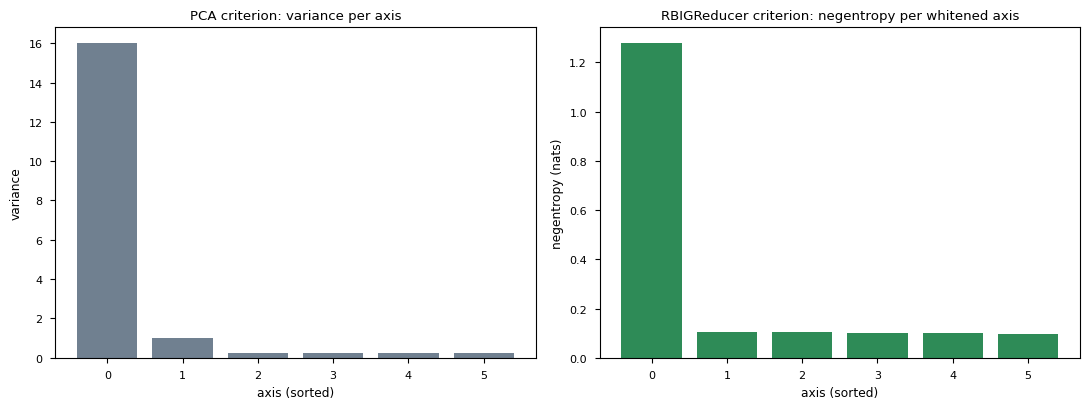

In [4]:
variances = np.sort(X.var(axis=0))[::-1]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.2))
ax0.bar(range(len(variances)), variances, color="slategray")
ax0.set_title("PCA criterion: variance per axis")
ax0.set_xlabel("axis (sorted)")
ax0.set_ylabel("variance")

ax1.bar(range(len(spectrum)), spectrum, color="seagreen")
ax1.set_title("RBIGReducer criterion: negentropy per whitened axis")
ax1.set_xlabel("axis (sorted)")
ax1.set_ylabel("negentropy (nats)")
plt.tight_layout()
plt.show()

## Which axis carries the signal?

The kept axes should reconstruct the bimodal structure, not the
high-variance Gaussian. We check the negentropy ranking directly.

In [5]:
print("per-axis negentropy (nats):", np.round(red.negentropies_, 3))
print("kept axes (mask):", red.keep_mask_.astype(int))
print(f"explained negentropy ratio: {red.explained_negentropy_ratio_:.3f}")

per-axis negentropy (nats): [0.104 1.278 0.105 0.098 0.1   0.101]
kept axes (mask): [0 1 1 0 0 0]
explained negentropy ratio: 0.774


## Takeaways

- **Whitening is deliberate.** A fully converged RBIG latent space
  Gaussianizes every marginal, so per-axis negentropy there is ~0 and
  cannot rank anything. `RBIGReducer` ranks in the *whitened* space,
  where variance is removed (unit per axis) and negentropy is the only
  remaining signal.
- Use it when the informative directions are **not** the high-variance
  ones — multi-modality, skew, heavy tails hiding under a loud Gaussian
  nuisance. When structure and variance coincide, plain PCA is fine.
- `inverse_transform` zero-fills the pruned axes (the max-entropy
  imputation), so the reconstruction error is exactly the discarded
  structure.